# Best Method IQ Benchmark (Main Notebook)

This notebook runs the benchmark for the selected best IQ method (default: Metodo 3 IQ) using local SigMF files from the db path.

It measures and plots computational cost:
- File loading time
- IQ conversion time
- Welch PSD time
- Metric extraction time
- KDE time
- Total runtime and memory

In [10]:
print("H")

H


In [11]:
# If needed, install dependencies first:
# %pip install numpy scipy matplotlib psutil

import os
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import psutil
from scipy.signal import welch
from scipy.stats import gaussian_kde

print("Dependencies imported successfully.")

Dependencies imported successfully.


In [12]:
# ================================
# Configuration
# ================================
BEST_METHOD_NAME = "Metodo 3 IQ"

DB_ROOT = Path(r"D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\db")
DATASET_DIR = DB_ROOT / "DataBase-IQ-FM-88MHz-108MHz"

# Keep this small for quick profiling, increase for stronger statistics
N_FILES = 20 # change to 6 for quick test. 
N_PERSEG = 2048
KDE_GRID_POINTS = 256

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}")

print(f"Best method selected: {BEST_METHOD_NAME}")
print(f"DB root traced: {DB_ROOT}")
print(f"Dataset dir: {DATASET_DIR}")

Best method selected: Metodo 3 IQ
DB root traced: D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\db
Dataset dir: D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\db\DataBase-IQ-FM-88MHz-108MHz


In [13]:
# ================================
# File selection (best available local files)
# Strategy: pick largest SigMF captures with matching meta/data
# ================================
data_files = sorted(DATASET_DIR.glob("*.sigmf-data"))

pairs = []
for d in data_files:
    m = d.with_suffix("").with_suffix(".sigmf-meta")
    if m.exists():
        pairs.append((d, m, d.stat().st_size))

if not pairs:
    raise RuntimeError("No valid .sigmf-data/.sigmf-meta pairs found.")

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:N_FILES]

print(f"Selected {len(pairs)} files for benchmark:")
for i, (d, m, sz) in enumerate(pairs, start=1):
    print(f"{i:02d}. {d.name} | {sz/1024/1024:.2f} MB")

Selected 6 files for benchmark:
01. 01_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
02. 02_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
03. 03_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
04. 04_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
05. 05_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
06. 06_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB


In [14]:
# ================================
# Benchmark helpers
# ================================
def load_sigmf_pair(data_path: Path, meta_path: Path):
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    with open(data_path, "rb") as f:
        raw_int8 = np.frombuffer(f.read(), dtype=np.int8)

    fs = int(meta["global"]["core:sample_rate"])
    fc = int(meta["captures"][0]["core:frequency"])

    return raw_int8, fs, fc


def to_complex_iq(raw_int8: np.ndarray):
    if raw_int8.size % 2 != 0:
        raw_int8 = raw_int8[:-1]
    i = raw_int8[0::2].astype(np.float32)
    q = raw_int8[1::2].astype(np.float32)
    return i + 1j * q


def compute_psd_metrics(iq_complex: np.ndarray, fs: int, nperseg: int = 2048):
    iq_centered = iq_complex - np.mean(iq_complex)
    f, pxx = welch(iq_centered, fs=fs, nperseg=min(nperseg, len(iq_centered)), return_onesided=False)

    f_shifted = np.fft.fftshift(f)
    pxx_db = 10.0 * np.log10(np.fft.fftshift(pxx) + 1e-12)

    noise_floor_dbm = float(np.mean(pxx_db))
    f_center = 0.5 * (f_shifted[0] + f_shifted[-1])
    idx_center = int(np.argmin(np.abs(f_shifted - f_center)))
    p_center_dbm = float(pxx_db[idx_center])
    snr_center_db = float(p_center_dbm - noise_floor_dbm)

    return f_shifted, pxx_db, noise_floor_dbm, p_center_dbm, snr_center_db


def safe_kde(samples, grid_points=256):
    x = np.asarray(samples, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return None, None

    xmin, xmax = np.min(x), np.max(x)
    xr = xmax - xmin if xmax > xmin else 1.0
    margin = 0.2 * xr
    grid = np.linspace(xmin - margin, xmax + margin, grid_points)

    kde = gaussian_kde(x, bw_method="scott")
    y = kde(grid)
    return grid, y

In [15]:
# ================================
# Run benchmark
# ================================
proc = psutil.Process()
rss_start_mb = proc.memory_info().rss / (1024 * 1024)
t0_total = time.perf_counter()

timing = {
    "load_ms": [],
    "convert_ms": [],
    "welch_ms": [],
    "metric_ms": [],
}

noise_vals = []
center_vals = []
snr_vals = []
file_labels = []
file_total_ms = []

for data_path, meta_path, _ in pairs:
    t_file = time.perf_counter()

    t0 = time.perf_counter()
    raw_iq, fs, fc = load_sigmf_pair(data_path, meta_path)
    timing["load_ms"].append((time.perf_counter() - t0) * 1000.0)

    t0 = time.perf_counter()
    iq = to_complex_iq(raw_iq)
    timing["convert_ms"].append((time.perf_counter() - t0) * 1000.0)

    t0 = time.perf_counter()
    f, pxx_db, nf, pc, snr = compute_psd_metrics(iq, fs, nperseg=N_PERSEG)
    welch_elapsed = (time.perf_counter() - t0) * 1000.0
    timing["welch_ms"].append(welch_elapsed)

    t0 = time.perf_counter()
    _ = (nf, pc, snr)
    timing["metric_ms"].append((time.perf_counter() - t0) * 1000.0)

    noise_vals.append(nf)
    center_vals.append(pc)
    snr_vals.append(snr)

    file_labels.append(data_path.stem.split("_")[0])
    file_total_ms.append((time.perf_counter() - t_file) * 1000.0)

t0 = time.perf_counter()
kde_noise = safe_kde(noise_vals, grid_points=KDE_GRID_POINTS)
kde_center = safe_kde(center_vals, grid_points=KDE_GRID_POINTS)
kde_snr = safe_kde(snr_vals, grid_points=KDE_GRID_POINTS)
kde_ms = (time.perf_counter() - t0) * 1000.0

total_ms = (time.perf_counter() - t0_total) * 1000.0
rss_end_mb = proc.memory_info().rss / (1024 * 1024)

summary = {
    "best_method": BEST_METHOD_NAME,
    "files": len(pairs),
    "samples_total": int(sum(len(to_complex_iq(load_sigmf_pair(d, m)[0])) for d, m, _ in pairs)),
    "load_ms_total": float(np.sum(timing["load_ms"])),
    "convert_ms_total": float(np.sum(timing["convert_ms"])),
    "welch_ms_total": float(np.sum(timing["welch_ms"])),
    "metric_ms_total": float(np.sum(timing["metric_ms"])),
    "kde_ms_total": float(kde_ms),
    "total_ms": float(total_ms),
    "rss_start_mb": float(rss_start_mb),
    "rss_end_mb": float(rss_end_mb),
    "rss_delta_mb": float(rss_end_mb - rss_start_mb),
    "snr_mean_db": float(np.mean(snr_vals)),
    "snr_std_db": float(np.std(snr_vals, ddof=1)) if len(snr_vals) > 1 else 0.0,
    "noise_mean_dbm": float(np.mean(noise_vals)),
    "center_mean_dbm": float(np.mean(center_vals)),
}

print("=" * 88)
print("BEST METHOD BENCHMARK SUMMARY")
print("=" * 88)
for k, v in summary.items():
    print(f"{k:20s}: {v}")

BEST METHOD BENCHMARK SUMMARY
best_method         : Metodo 3 IQ
files               : 6
samples_total       : 157286400
load_ms_total       : 875.2327999100089
convert_ms_total    : 2481.1758000287227
welch_ms_total      : 36182.09349992685
metric_ms_total     : 0.01409999094903469
kde_ms_total        : 4.997199983336031
total_ms            : 39544.82300003292
rss_start_mb        : 384.296875
rss_end_mb          : 384.26171875
rss_delta_mb        : -0.03515625
snr_mean_db         : 3.004906972249349
snr_std_db          : 0.05224979900355979
noise_mean_dbm      : -74.48205693562825
center_mean_dbm     : -71.4771499633789


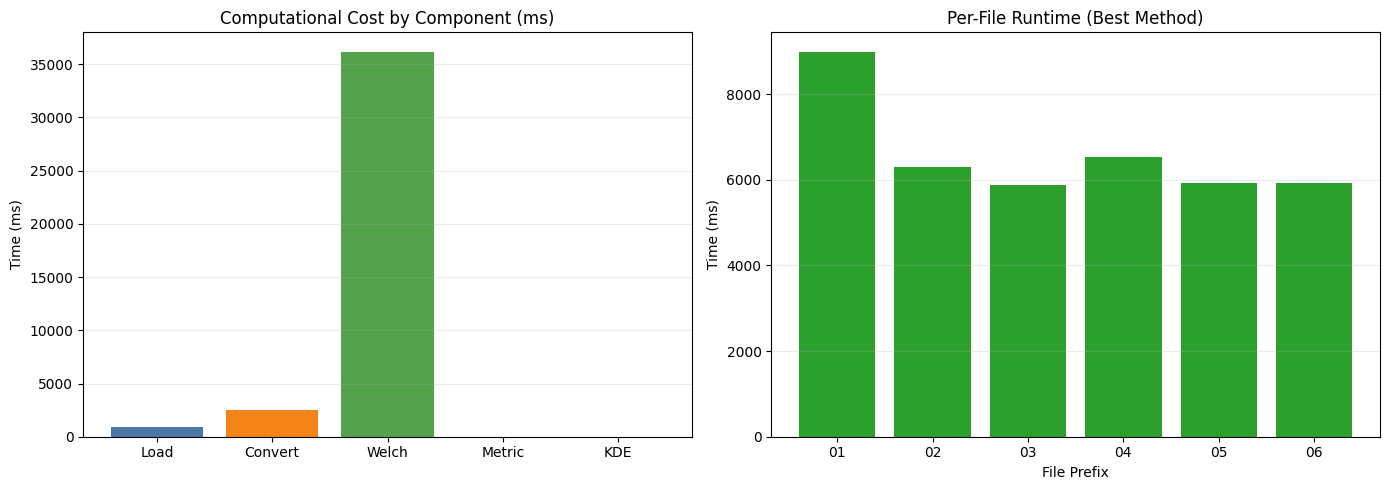

In [16]:
# ================================
# Plot computational cost
# ================================
cost_labels = ["Load", "Convert", "Welch", "Metric", "KDE"]
cost_values = [
    summary["load_ms_total"],
    summary["convert_ms_total"],
    summary["welch_ms_total"],
    summary["metric_ms_total"],
    summary["kde_ms_total"],
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cost_labels, cost_values, color=["#4c78a8", "#f58518", "#54a24b", "#e45756", "#72b7b2"])
axes[0].set_title("Computational Cost by Component (ms)")
axes[0].set_ylabel("Time (ms)")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(file_labels, file_total_ms, color="#2ca02c")
axes[1].set_title("Per-File Runtime (Best Method)")
axes[1].set_xlabel("File Prefix")
axes[1].set_ylabel("Time (ms)")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

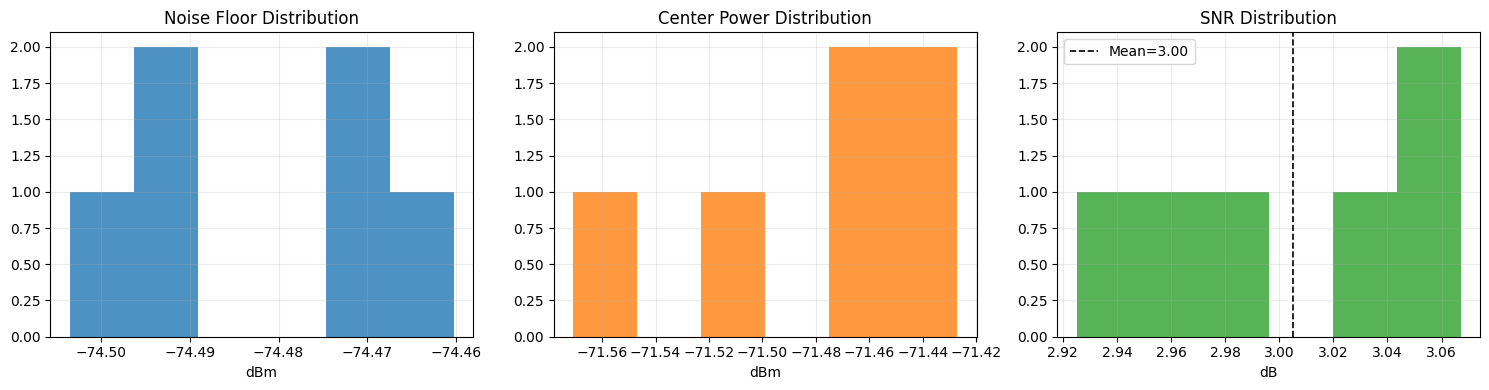

In [17]:
# ================================
# Plot KPI distributions for best method
# ================================
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(noise_vals, bins=min(10, max(3, len(noise_vals))), color="#1f77b4", alpha=0.8)
ax[0].set_title("Noise Floor Distribution")
ax[0].set_xlabel("dBm")
ax[0].grid(alpha=0.25)

ax[1].hist(center_vals, bins=min(10, max(3, len(center_vals))), color="#ff7f0e", alpha=0.8)
ax[1].set_title("Center Power Distribution")
ax[1].set_xlabel("dBm")
ax[1].grid(alpha=0.25)

ax[2].hist(snr_vals, bins=min(10, max(3, len(snr_vals))), color="#2ca02c", alpha=0.8)
ax[2].axvline(np.mean(snr_vals), linestyle="--", color="black", linewidth=1.2, label=f"Mean={np.mean(snr_vals):.2f}")
ax[2].set_title("SNR Distribution")
ax[2].set_xlabel("dB")
ax[2].grid(alpha=0.25)
ax[2].legend()

plt.tight_layout()
plt.show()

In [18]:
# Save benchmark output for C comparison
out_path = Path("best_method_python_metrics.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Saved metrics to: {out_path.resolve()}")

Saved metrics to: D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\spectrumAnalysis\narrowband\preprocess\src\test\prslIQ\best_method_python_metrics.json


In [19]:
# Derived KPIs that matter for optimization decisions
samples_total = summary["samples_total"]
total_s = summary["total_ms"] / 1000.0

throughput_sps = samples_total / total_s if total_s > 0 else 0.0
avg_file_ms = summary["total_ms"] / summary["files"] if summary["files"] > 0 else 0.0

parts = {
    "Load": summary["load_ms_total"],
    "Convert": summary["convert_ms_total"],
    "Welch": summary["welch_ms_total"],
    "Metric": summary["metric_ms_total"],
    "KDE": summary["kde_ms_total"],
}

print("=" * 88)
print("CRITICAL PERFORMANCE KPIs")
print("=" * 88)
print(f"Best method                 : {summary['best_method']}")
print(f"Files processed             : {summary['files']}")
print(f"Total samples               : {samples_total:,}")
print(f"Total runtime               : {summary['total_ms']:.2f} ms")
print(f"Avg runtime per file        : {avg_file_ms:.2f} ms")
print(f"Throughput                  : {throughput_sps:,.2f} samples/s")
print(f"SNR mean +- std             : {summary['snr_mean_db']:.4f} +- {summary['snr_std_db']:.4f} dB")
print(f"Noise floor mean            : {summary['noise_mean_dbm']:.4f} dBm")
print(f"Center power mean           : {summary['center_mean_dbm']:.4f} dBm")
print(f"RSS delta                   : {summary['rss_delta_mb']:.4f} MB")

print("\nComponent share of measured total:")
for name, val in parts.items():
    pct = 100.0 * val / summary["total_ms"] if summary["total_ms"] > 0 else 0.0
    print(f"- {name:7s}: {val:10.3f} ms ({pct:6.2f}%)")

print("\nOptimization priority:")
ranked = sorted(parts.items(), key=lambda x: x[1], reverse=True)
for i, (name, val) in enumerate(ranked, start=1):
    print(f"{i}. {name} ({val:.3f} ms)")

CRITICAL PERFORMANCE KPIs
Best method                 : Metodo 3 IQ
Files processed             : 6
Total samples               : 157,286,400
Total runtime               : 39544.82 ms
Avg runtime per file        : 6590.80 ms
Throughput                  : 3,977,420.76 samples/s
SNR mean +- std             : 3.0049 +- 0.0522 dB
Noise floor mean            : -74.4821 dBm
Center power mean           : -71.4771 dBm
RSS delta                   : -0.0352 MB

Component share of measured total:
- Load   :    875.233 ms (  2.21%)
- Convert:   2481.176 ms (  6.27%)
- Welch  :  36182.093 ms ( 91.50%)
- Metric :      0.014 ms (  0.00%)
- KDE    :      4.997 ms (  0.01%)

Optimization priority:
1. Welch (36182.093 ms)
2. Convert (2481.176 ms)
3. Load (875.233 ms)
4. KDE (4.997 ms)
5. Metric (0.014 ms)
